In [1]:
# Start with the imports

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Module to save models onces are fitted to the data
import pickle

In [2]:
# import raw data

churn_raw = pd.read_csv('./raw_data/Churn_Modelling.csv')
churn_raw.head(15)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [3]:
# Drop columns data will not be necessary for the model
# Feature Selection

churn_data = churn_raw.drop(['RowNumber','CustomerId','Surname','Gender'], axis=1)
churn_data.head()

,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,41,1,83807.86,1,0,1,112542.58,0
2,502,France,42,8,159660.80,3,1,0,113931.57,1
3,699,France,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# Check for nulls

churn_data.isna().sum()

CreditScore        0
Geography          0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [5]:
# Feature Transform
# There a single column that is categorical, which is Geography

churn_data['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

I have two wasy to handle the categorical Data, one is One-Hot encoding, the other one is the Label encoding
The problem with the Label Encoding is that I will be introducing a little bit of bias to the model. 

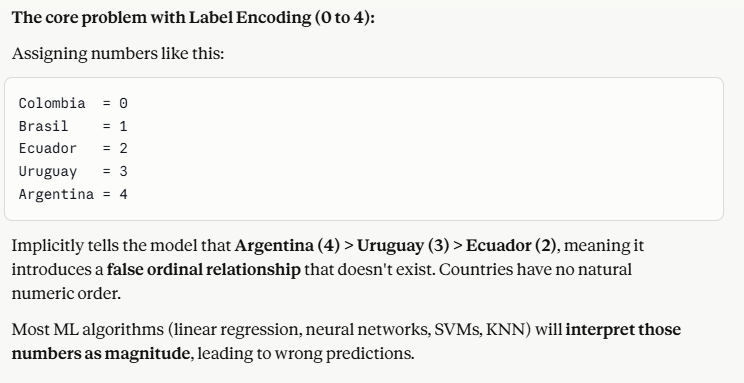

Reference for use based on which model I will be using or building 

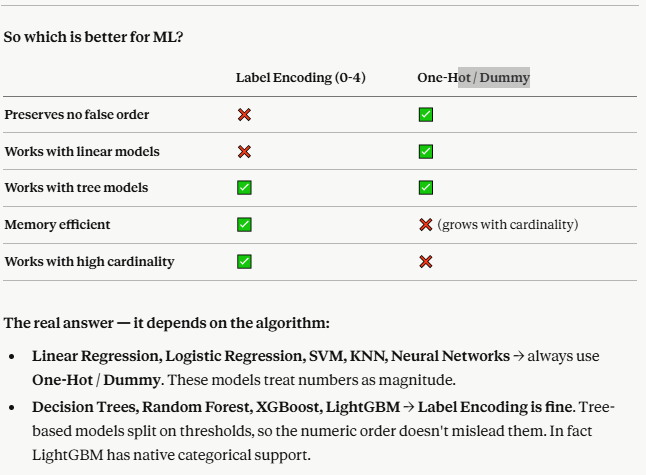

In this case since I'm building a Random Forest model, Label Encoding will not harm the model.
Eben though in a real-world escenario a One-Hot encoding is a better and safer option.

In [6]:
# Label Encoding Option
churn_data['Geography'] = churn_data['Geography'].map({'France':0,'Spain':1,'Germany':2})
churn_data.head()

,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,42,2,0.00,1,1,1,101348.88,1
1,608,1,41,1,83807.86,1,0,1,112542.58,0
2,502,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,39,1,0.00,2,0,0,93826.63,0
4,850,1,43,2,125510.82,1,1,1,79084.10,0


In [7]:
# Split data for training and test

y = churn_data['Exited']
x = churn_data.drop(['Exited'],axis =1)

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)

try: 
    with open('./models/randomForestModel.pickle','rb') as model_read:
        rf_model = pickle.load(model_read)
except:
    randomForestModel = RandomForestClassifier(random_state=0)

    hyperParams = {
        'max_depth':[2,4,6,8],
        'min_samples_split':[5,10,15],
        'max_features': [3,5],
        'n_estimators':[50,75,100,125,200] #Number of Base Learners that the model will create
    }

    rf_crossValidation = GridSearchCV(randomForestModel,hyperParams,scoring='f1',cv=5,refit='f1')
    rf_crossValidation.fit(x_train,y_train)

In [8]:
try: 
    rf_crossValidation.best_estimator_
except: pass

### Pickle
When models take a long time to fit, I don’t want to have to fit them more than once. 

pickle is a tool that saves the fit model object to a specified location, then quickly reads it back in. It also allows to use models that were fit somewhere else, without having to train them yourself.

In [9]:
# save the model
'''
with open('./models/randomForestModel.pickle','wb') as model_write:
    pickle.dump(rf_crossValidation,model_write)
'''

"\nwith open('./models/randomForestModel.pickle','wb') as model_write:\n    pickle.dump(rf_crossValidation,model_write)\n"

In [10]:
# To load the model without needing to retrain it
'''
with open('./models/randomForestModel.pickle','rb') as model_read:
    rf_model = pickle.load(model_read)
'''

"\nwith open('./models/randomForestModel.pickle','rb') as model_read:\n    rf_model = pickle.load(model_read)\n"

In [11]:
rf_model.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",125
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",15
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_true

In [12]:
rf_model.best_score_

np.float64(0.5626099148988644)

In [13]:
print(rf_model.cv_results_.keys())

best_results = pd.DataFrame(rf_model.cv_results_)

best_results[best_results['rank_test_score']== 1]

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_max_depth', 'param_max_features', 'param_min_samples_split', 'param_n_estimators', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score'])


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
118,0.938759,0.013095,0.02763,0.0001,8,5,15,125,"{'max_depth': 8, 'max_features': 5, 'min_sampl...",0.537585,0.545035,0.59081,0.570175,0.569444,0.56261,0.019154,1


## Modeling

First create a set that will be used to validate the data but will not be part of the **test data** is a validation set

In [15]:
# data validation creation

x_tr, x_val, y_tr, y_val = train_test_split(x_train,y_train,test_size=0.2,random_state=10,stratify=y_train)

When we tune hyperparameters with `GridSearchCV` using a separate validation dataset, we have to take a few extra steps. `GridSearchCV` wants to cross-validate the data. In fact, if the `cv` argument were left blank, it would split the data into five folds for cross-validation by default. 

We don't want it to do this. Instead, we're going to tell it exactly which rows of `X_train` are for training, and which rows are for validation.  

To do this, we need to make a list of length `len(X_train)` where each element is either a 0 or -1. A 0 in index _i_ will indicate to `GridSearchCV` that index _i_ of `X_train` is to be held out for validation. A -1 at a given index will indicate that that index of `X_train` is to be used as training data. 

We'll make this list using a list comprehension that looks at the index number of each row in `X_train`. If that index number is in `X_val`'s list of index numbers, then the list comprehension appends a 0. If it's not, then it appends a -1.

So if our training data is:  
[A, B, C, D],  
and our list is:   
[-1, 0, 0, -1],  
then `GridSearchCV` will use a training set of [A, D] and validation set of [B, C].
***
*The hole piece of text was extracted from coursera guide: Annotated follow-along guide_ Build and cross-validate a random forest model with Python*

In [18]:
x_tr.head()

,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
7682,700,1,29,8,0.00,2,0,1,152097.02
5748,645,0,45,8,85325.93,1,0,0,22558.74
2972,641,1,42,9,132657.55,1,1,0,35367.19
4976,828,2,25,7,144351.86,1,1,0,116613.26
2547,682,1,59,0,122661.39,1,0,1,84803.76


In [26]:
x_val.index

Index([6379, 6267, 6956, 5488, 4299, 9678,  220, 5878, 8962,  444,
       ...
        849, 2176, 1623, 9484, 7134, 9433, 8230, 9689, 1028, 1237],
      dtype='int64', length=1400)

In [44]:
x_train['validation_data'] = x_train.apply(lambda row: 0 if row.name in x_val.index else -1, axis=1)
# row.name holds the index value of each row when applying along axis=1.

In [48]:
# Now that we have this list, we need to import a new function called PredefinedSplit. 
# This function is what allows us to pass the list we just made to GridSearchCV. 

from sklearn.model_selection import PredefinedSplit

In [55]:
rf_validated = RandomForestClassifier(random_state=0)

# Same hyperparameters set to train the first cross validation
hyperParams = {
    'max_depth':[2,4,6,8],
    'min_samples_split':[5,10,15],
    'max_features': [3,5],
    'n_estimators':[50,75,100,125,200] #Number of Base Learners that the model will create
}
hyperParamsVal = hyperParams

validation_split = PredefinedSplit(x_train.loc[:,'validation_data'])

rf_validation = GridSearchCV(rf_validated,scoring='f1',param_grid=hyperParamsVal,cv=validation_split,refit='f1')

In [56]:
rf_validation.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 4, ...], 'max_features': [3, 5], 'min_samples_split': [5, 10, ...], 'n_estimators': [50, 75, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.","PredefinedSpl...hape=(7000,)))"
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time f

In [57]:
rf_validation.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",125
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",15
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_true

In [58]:
rf_validation.best_score_

np.float64(0.562929061784897)

In [ ]:
with open('./models/randomForestModel_SeparatedValidationSet.pickle','wb') as model_write:
    pickle.dump(rf_validation,model_write)